In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('~/Desktop/kaggle_survey_2022_responses.csv')
df.head()

/var/folders/7m/16c73fl57sd3qqk7qs_575zr0000gn/T/ipykernel_771/309631204.py:7: DtypeWarning: Columns (0: Duration (in seconds), 1: Q6_11, 2: Q12_14, 3: Q13_13, 4: Q14_15, 5: Q15_14, 6: Q17_14, 7: Q18_13, 8: Q19_7, 9: Q20_5, 10: Q31_11, 11: Q35_15, 12: Q36_7, 13: Q36_14, 14: Q37_9, 15: Q39_11, 16: Q40_6, 17: Q40_8, 18: Q40_11, 19: Q41_6, 20: Q41_7, 21: Q41_8, 22: Q42_4, 23: Q42_8, 24: Q44_11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('~/Desktop/kaggle_survey_2022_responses.csv')


,Duration (in seconds),Q2,Q3,Q4,Q5,Q6_1,Q6_2,Q6_3,Q6_4,Q6_5,...,Q44_3,Q44_4,Q44_5,Q44_6,Q44_7,Q44_8,Q44_9,Q44_10,Q44_11,Q44_12
0,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,"Are you currently a student? (high school, uni...",On which platforms have you begun or completed...,On which platforms have you begun or completed...,On which platforms have you begun or completed...,On which platforms have you begun or completed...,On which platforms have you begun or completed...,...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...
1,121,30-34,Man,India,No,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,462,30-34,Man,Algeria,No,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,293,18-21,Man,Egypt,Yes,Coursera,edX,NaN,DataCamp,NaN,...,NaN,"Kaggle (notebooks, forums, etc)",NaN,"YouTube (Kaggle YouTube, Cloud AI Adventures, ...","Podcasts (Chai Time Data Science, O’Reilly Dat...",NaN,NaN,NaN,NaN,NaN
4,851,55-59,Man,France,No,Coursera,NaN,Kaggle Learn Courses,NaN,NaN,...,NaN,"Kaggle (notebooks, forums, etc)","Course Forums (forums.fast.ai, Coursera forums...",NaN,NaN,"Blogs (Towards Data Science, Analytics Vidhya,...",NaN,NaN,NaN,NaN


#### DIRECTIONS TO EXPLORE

1) Load the survey dataset and inspect its structure: column names, data types, missing values.
2) Clean the data: standardize inconsistent responses and handle nulls.
3) Analyze which programming languages, tools, and platforms are most commonly reported.
4) Break down results by experience level or job title.
5) Visualize findings with bar charts and frequency tables.
6) Write a short summary: what would the data tell someone starting in data science today?


## INVESTIGATE THE DATAFRAME STRUCTURE

In [156]:
df.describe().T

,count,unique,top,freq
Duration (in seconds),23998,4329,230,59
Q2,23998,12,18-21,4559
Q3,23998,6,Man,18266
Q4,23998,59,India,8792
Q5,23998,3,No,12036
...,...,...,...,...
Q44_8,7767,2,"Blogs (Towards Data Science, Analytics Vidhya,...",7766
Q44_9,3805,2,"Journal Publications (peer-reviewed journals, ...",3804
Q44_10,1727,2,"Slack Communities (ods.ai, kagglenoobs, etc)",1726
Q44_11,1,1,Who/what are your favorite media sources that ...,1


In [157]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23998 entries, 0 to 23997
Columns: 296 entries, Duration (in seconds) to Q44_12
dtypes: object(1), str(295)
memory usage: 54.2+ MB


In [158]:
df.columns

Index(['Duration (in seconds)', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6_1', 'Q6_2', 'Q6_3',
       'Q6_4', 'Q6_5',
       ...
       'Q44_3', 'Q44_4', 'Q44_5', 'Q44_6', 'Q44_7', 'Q44_8', 'Q44_9', 'Q44_10',
       'Q44_11', 'Q44_12'],
      dtype='str', length=296)

In [159]:
# Columns by type
print(df.select_dtypes(include='str').columns)
print(df.select_dtypes(exclude='str').columns)

Index(['Q2', 'Q3', 'Q4', 'Q5', 'Q6_1', 'Q6_2', 'Q6_3', 'Q6_4', 'Q6_5', 'Q6_6',
       ...
       'Q44_3', 'Q44_4', 'Q44_5', 'Q44_6', 'Q44_7', 'Q44_8', 'Q44_9', 'Q44_10',
       'Q44_11', 'Q44_12'],
      dtype='str', length=295)
Index(['Duration (in seconds)'], dtype='str')


In [160]:
# Explore a specific question with multiple choices (for example)
df[[col for col in df.columns if 'Q6' in col]].head()
df[[col for col in df.columns if 'Q31' in col]].head()
df[[col for col in df.columns if 'Q39' in col]].head()
#df[[col for col in df.columns if 'Q44' in col]].head()

,Q39_1,Q39_2,Q39_3,Q39_4,Q39_5,Q39_6,Q39_7,Q39_8,Q39_9,Q39_10,Q39_11,Q39_12
0,Do you use any of the following products to se...,Do you use any of the following products to se...,Do you use any of the following products to se...,Do you use any of the following products to se...,Do you use any of the following products to se...,Do you use any of the following products to se...,Do you use any of the following products to se...,Do you use any of the following products to se...,Do you use any of the following products to se...,Do you use any of the following products to se...,Do you use any of the following products to se...,Do you use any of the following products to se...
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,ONNX Runtime,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [161]:
# Explore all quesitons without multiple choices
q_no_choice = df[[col for col in df.columns if '_' not in col]].columns

q_dict = {}
for q in q_no_choice.tolist():
    q_dict[q] = df.iloc[0][q]
q_dict

{'Duration (in seconds)': 'Duration (in seconds)',
 'Q2': 'What is your age (# years)?',
 'Q3': 'What is your gender? - Selected Choice',
 'Q4': 'In which country do you currently reside?',
 'Q5': 'Are you currently a student? (high school, university, or graduate)',
 'Q8': 'What is the highest level of formal education that you have attained or plan to attain within the next 2 years?',
 'Q9': 'Have you ever published any academic research (papers, preprints, conference proceedings, etc)?',
 'Q11': 'For how many years have you been writing code and/or programming?',
 'Q16': 'For how many years have you used machine learning methods?',
 'Q22': 'Which of the following ML model hubs/repositories do you use most often? - Selected Choice',
 'Q23': 'Select the title most similar to your current role (or most recent title if retired): - Selected Choice',
 'Q24': 'In what industry is your current employer/contract (or your most recent employer if retired)? - Selected Choice',
 'Q25': 'What is 

In [162]:
df[q_no_choice].isnull().mean() * 100

Duration (in seconds)     0.000000
Q2                        0.000000
Q3                        0.000000
Q4                        0.000000
Q5                        0.000000
Q8                        2.496041
Q9                       48.487374
Q11                       3.141928
Q16                      17.130594
Q22                      84.607051
Q23                      55.700475
Q24                      62.101008
Q25                      62.217685
Q26                      62.534378
Q27                      63.026086
Q29                      66.093008
Q30                      64.642887
Q32                      91.957663
Q43                      80.856738
dtype: float64

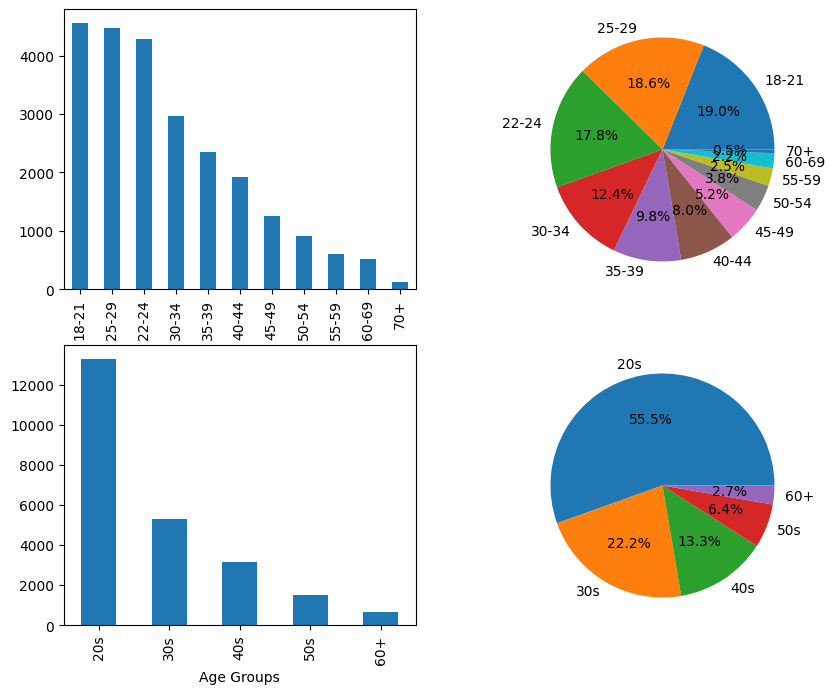

In [163]:
# Investigate age of participants
# 'Q2': 'What is your age (# years)?'
fig, ax = plt.subplots(2, 2, figsize=(10,8))
ax = ax.flatten()
df['Q2'].iloc[1:].value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_xlabel('Age Groups')

df['Q2'].iloc[1:].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1])

# Regroup age groups into broader categories for better investigation
# Map age groups to numeric values
map_dict = {
    '18-21': '20s',
    '22-24': '20s',
    '25-29': '20s',
    '30-34': '30s',
    '35-39': '30s',
    '40-44': '40s',
    '45-49': '40s',
    '50-54': '50s',
    '55-59': '50s',
    '60-69': '60+',
    '70+': '60+'
}
age_group = df['Q2'].map(map_dict)

age_group.iloc[1:].value_counts().plot(kind='bar', ax=ax[2])
ax[2].set_xlabel('Age Groups')

age_group.iloc[1:].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[3])
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

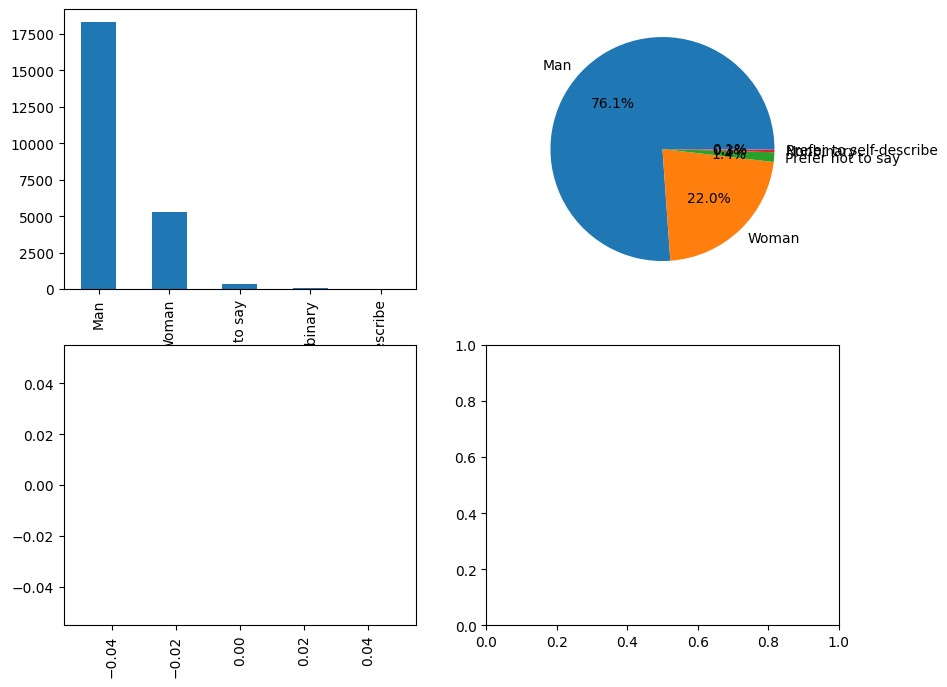

In [164]:
# Investigate Gender ratios
# 'Q3': 'What is your gender? - Selected Choice'
fig, ax = plt.subplots(2, 2, figsize=(10,8))
ax = ax.flatten()
df['Q3'].iloc[1:].value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_xlabel('Genders')

df['Q3'].iloc[1:].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1])

# Regroup gender categories into broader categories for better investigation
map_dict = {
    'man': 'male',
    'woman': 'female',
    'prefer not to say': 'Other',
    'nonbinary': 'Other',
    'prefer to self-describe': 'Other',
}
gender_group = df['Q3'].map(map_dict)

gender_group.iloc[1:].value_counts().plot(kind='bar', ax=ax[2])
ax[2].set_xlabel('Genders')

gender_group.iloc[1:].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[3])
plt.show()



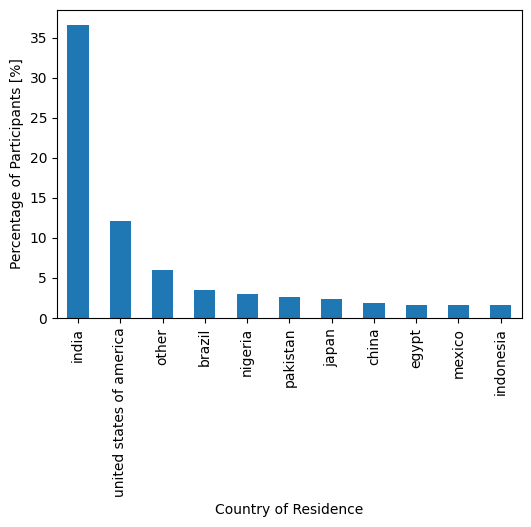

In [148]:
# Investigate country of residence
# 'Q4': 'In which country do you currently reside? - Selected Choice'

# Let's map non respondents to 'Other' for better visualization
df.loc[1:, 'Q4'] = df.loc[1:, 'Q4'].replace(
    'i do not wish to disclose my location',
    'Other'
)
total = df['Q4'].iloc[1:].value_counts().sum()
df_country = df['Q4'].iloc[1:].value_counts() / total * 100
df_country = df_country[df_country > 1.5]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
df_country.plot(kind='bar', ax=ax)
ax.set_xlabel('Country of Residence')
ax.set_ylabel('Percentage of Participants [%]')
plt.show()

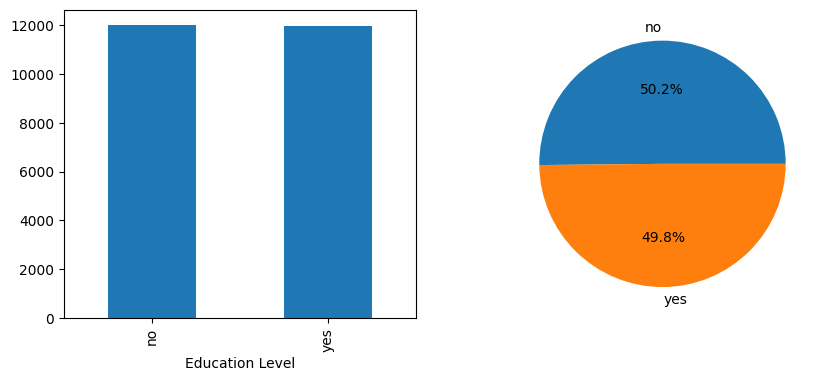

In [150]:
# Investigate education level 
# 'Q5': 'Are you currently a student? (high school, university, or graduate)',
fig, ax = plt.subplots(1, 2, figsize=(10,4))
df['Q5'].iloc[1:].value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_xlabel('Education Level')
df['Q5'].iloc[1:].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1])
plt.show()

In [153]:
# Now we can explore questions with multiple choices, for example
q_choice = df[[col.split('_')[0]+'_' for col in df.columns if '_' in col]].columns

q_dict = {}
for q in q_choice.tolist():
    q_dict[q] = df.iloc[0][q]
q_dict

KeyError: "None of [Index(['Q6_', 'Q6_', 'Q6_', 'Q6_', 'Q6_', 'Q6_', 'Q6_', 'Q6_', 'Q6_', 'Q6_',\n       ...\n       'Q44_', 'Q44_', 'Q44_', 'Q44_', 'Q44_', 'Q44_', 'Q44_', 'Q44_', 'age_',\n       'gender_'],\n      dtype='str', length=279)] are in the [columns]"

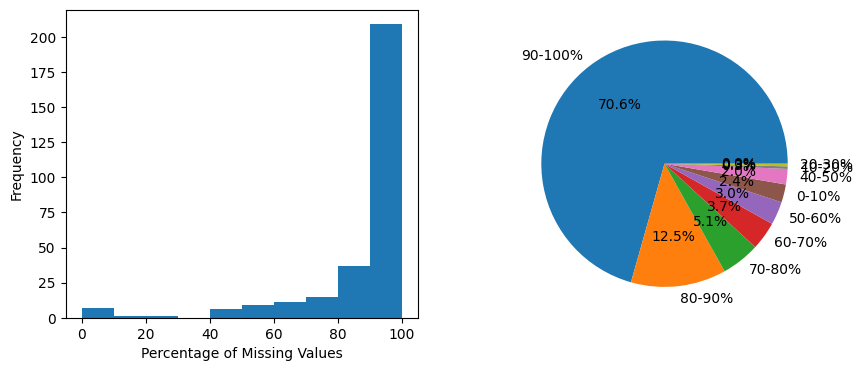

In [31]:
mean_null = df.isnull().mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
mean_null.plot(kind='hist', bins=10, range=(0, 100), ax=ax[0])
ax[0].set_xlabel('Percentage of Missing Values')

pd.cut(mean_null, bins=10, labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', 
                                   '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']).value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1])
plt.show()

In [39]:
mean_null

Q44_1     83.348612
Q44_2     84.215351
Q44_3     88.836570
Q44_4     53.404450
Q44_5     83.302775
Q44_6     50.170848
Q44_7     91.161763
Q44_8     67.634803
Q44_9     84.144512
Q44_10    92.803567
Q44_11    99.995833
Q44_12    96.516376
dtype: float64

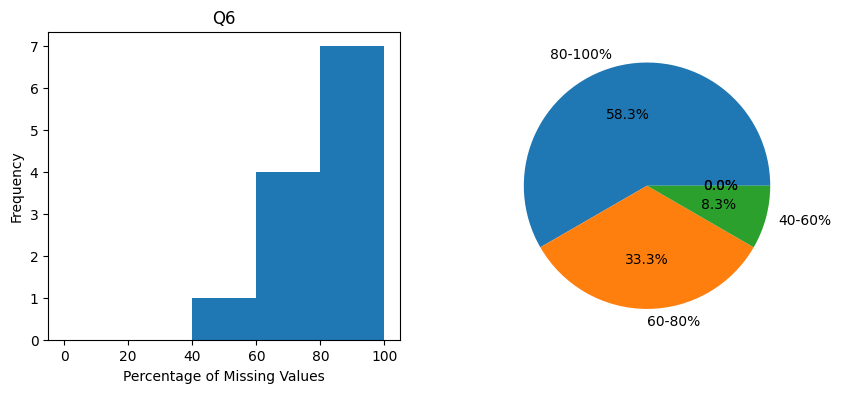

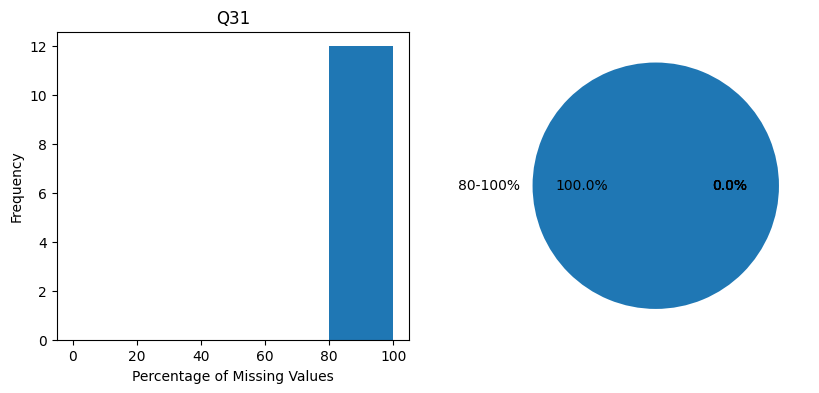

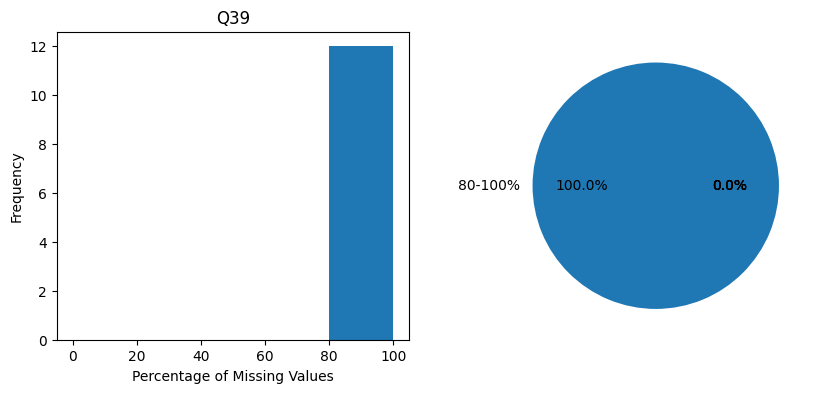

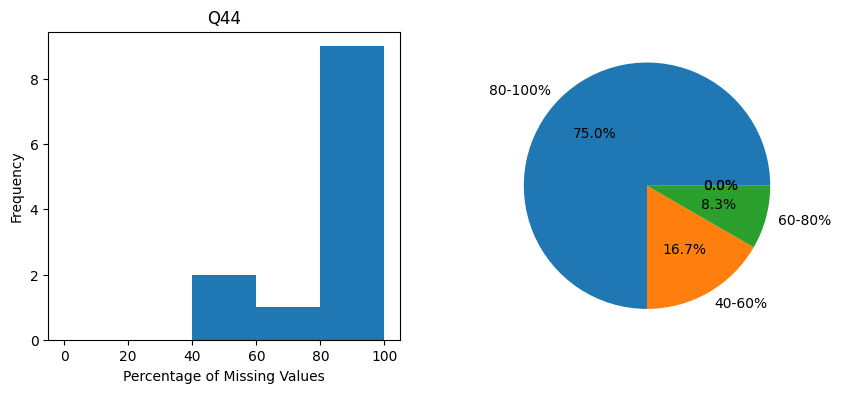

In [42]:
for q in ['Q6', 'Q31', 'Q39', 'Q44']:
    mean_null = df[[q+y for y in [f'_{i}' for i in range(1, 13)]]].isnull().mean() * 100
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].set_title(q)
    mean_null.plot(kind='hist', bins=5, range=(0, 100), ax=ax[0])
    ax[0].set_xlabel('Percentage of Missing Values')

    pd.cut(mean_null, bins=[0, 20, 40, 60, 80, 100], 
           labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']).value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1])
    plt.show()

In [36]:
df.columns.tolist()

['Duration (in seconds)',
 'Q2',
 'Q3',
 'Q4',
 'Q5',
 'Q6_1',
 'Q6_2',
 'Q6_3',
 'Q6_4',
 'Q6_5',
 'Q6_6',
 'Q6_7',
 'Q6_8',
 'Q6_9',
 'Q6_10',
 'Q6_11',
 'Q6_12',
 'Q7_1',
 'Q7_2',
 'Q7_3',
 'Q7_4',
 'Q7_5',
 'Q7_6',
 'Q7_7',
 'Q8',
 'Q9',
 'Q10_1',
 'Q10_2',
 'Q10_3',
 'Q11',
 'Q12_1',
 'Q12_2',
 'Q12_3',
 'Q12_4',
 'Q12_5',
 'Q12_6',
 'Q12_7',
 'Q12_8',
 'Q12_9',
 'Q12_10',
 'Q12_11',
 'Q12_12',
 'Q12_13',
 'Q12_14',
 'Q12_15',
 'Q13_1',
 'Q13_2',
 'Q13_3',
 'Q13_4',
 'Q13_5',
 'Q13_6',
 'Q13_7',
 'Q13_8',
 'Q13_9',
 'Q13_10',
 'Q13_11',
 'Q13_12',
 'Q13_13',
 'Q13_14',
 'Q14_1',
 'Q14_2',
 'Q14_3',
 'Q14_4',
 'Q14_5',
 'Q14_6',
 'Q14_7',
 'Q14_8',
 'Q14_9',
 'Q14_10',
 'Q14_11',
 'Q14_12',
 'Q14_13',
 'Q14_14',
 'Q14_15',
 'Q14_16',
 'Q15_1',
 'Q15_2',
 'Q15_3',
 'Q15_4',
 'Q15_5',
 'Q15_6',
 'Q15_7',
 'Q15_8',
 'Q15_9',
 'Q15_10',
 'Q15_11',
 'Q15_12',
 'Q15_13',
 'Q15_14',
 'Q15_15',
 'Q16',
 'Q17_1',
 'Q17_2',
 'Q17_3',
 'Q17_4',
 'Q17_5',
 'Q17_6',
 'Q17_7',
 'Q17_8',
 'Q17_9'

In [46]:
df.iloc[0]['Q39_1']

'Do you use any of the following products to serve your machine learning models?  (Select all that apply) - Selected Choice -  TensorFlow Extended (TFX) '